# 04 - Camino hasta modelos fuertes

Este notebook resume la evolucion que llevo desde modelos simples hasta sistemas de alto rendimiento. No define la entrega final; explica como se llego a tener componentes buenos para elegir.


In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'sample_submission.csv').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('No pude encontrar la raiz del repo')
    ROOT = ROOT.parent

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

pd.set_option('display.max_colwidth', 120)

RESULTS = ROOT / '04_experimentacion_camino' / 'results'
FIGURES = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

milestones = pd.DataFrame([
    {'stage': 'priors / formato', 'idea': 'submission valida sin audio real', 'private_lb': None, 'takeaway': 'sirve como smoke test, no como modelo'},
    {'stage': 'sklearn log-mel stats', 'idea': 'estadisticas tabulares sobre log-mel', 'private_lb': 0.37607, 'takeaway': 'usa informacion acustica pero pierde el tiempo'},
    {'stage': 'CNN log-mel', 'idea': 'imagen log-mel 128 x 512', 'private_lb': 0.52257, 'takeaway': 'preservar tiempo-frecuencia mejora mucho'},
    {'stage': 'head256 / entrenamiento neural', 'idea': 'He, BatchNorm, dropout, scheduler y cabeza densa', 'private_lb': 0.64665, 'takeaway': 'mejora la capacidad y estabilidad'},
    {'stage': 'separable_headsep', 'idea': 'CNN separable-residual con cabeza densa', 'private_lb': 0.65289, 'takeaway': 'bloque convolucional fuerte y eficiente'},
    {'stage': 'globalmel_sep_temporal', 'idea': 'normalizacion global mel + BiGRU temporal', 'private_lb': 0.66561, 'takeaway': 'normalizacion y temporalidad aportan diversidad'},
    {'stage': 'f1024 + historico expandido', 'idea': 'contexto temporal 1024 dentro de blend expandido', 'private_lb': 0.67025, 'takeaway': 'contexto largo ayuda, aunque el blend era dificil de defender'},
])
milestones.to_csv(RESULTS / 'camino_modelos_fuertes.csv', index=False)
display(milestones)


,stage,idea,private_lb,takeaway
0,priors / formato,submission valida sin audio real,NaN,"sirve como smoke test, no como modelo"
1,sklearn log-mel stats,estadisticas tabulares sobre log-mel,0.37607,usa informacion acustica pero pierde el tiempo
2,CNN log-mel,imagen log-mel 128 x 512,0.52257,preservar tiempo-frecuencia mejora mucho
3,head256 / entrenamiento neural,"He, BatchNorm, dropout, scheduler y cabeza densa",0.64665,mejora la capacidad y estabilidad
4,separable_headsep,CNN separable-residual con cabeza densa,0.65289,bloque convolucional fuerte y eficiente
5,globalmel_sep_temporal,normalizacion global mel + BiGRU temporal,0.66561,normalizacion y temporalidad aportan diversidad
6,f1024 + historico expandido,contexto temporal 1024 dentro de blend expandido,0.67025,"contexto largo ayuda, aunque el blend era dificil de defender"


## Lectura del camino

La tendencia importante no es cada numero aislado, sino la direccion:

```text
estadisticas globales -> imagen log-mel -> CNN mejor entrenada -> ramas temporales/diversas
```

Esa lectura justifica que el final use tres vistas log-mel distintas.


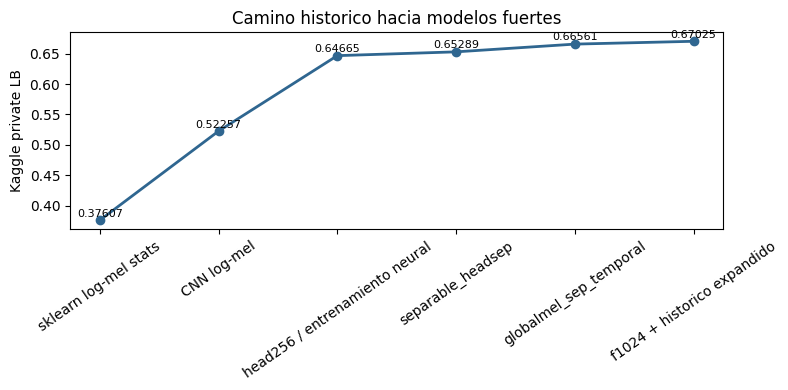

In [2]:
plot_df = milestones.dropna(subset=['private_lb']).copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(plot_df['stage'], plot_df['private_lb'], marker='o', linewidth=2, color='#2f6690')
ax.set_ylabel('Kaggle private LB')
ax.set_title('Camino historico hacia modelos fuertes')
ax.tick_params(axis='x', rotation=35)
for idx, value in enumerate(plot_df['private_lb']):
    ax.text(idx, value + 0.006, f'{value:.5f}', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'camino_private_lb.png', dpi=160)
plt.show()


## Conclusion

Las ramas finales no aparecen de golpe. Son la condensacion de lo que funciono: log-mel como representacion, CNN separable-residual como extractor local y ramas temporales para modelar evolucion/contexto.
